# Main experiments setup

## Robust optimization approach

In [1]:
import json
from pathlib import Path
import numpy as np

from visualization import ExperimentVisualizer
from run_experiments import (
    run_robust_experiments,
    run_stochastic_experiments,
    run_scaling_experiments,
    run_out_of_sample_validation,
)

In [2]:
N_VALUES = list(range(5, 21, 5))
ALPHA_VALUES = [0.5, 0.90]
NUM_INSTANCES = 50
K = 30
SEED = 42

visualizer = ExperimentVisualizer()

In [3]:
def save_results(result: dict, out_path: Path):
    with open(out_path, "w") as f:
        json.dump(result, f)

In [4]:
robust_results = {}
for N in N_VALUES:
    print(f"\nRunning robust experiments for n={N}")
    result = run_robust_experiments(N, num_instances=NUM_INSTANCES)
    robust_results[N] = result

save_results(robust_results, Path("experiments/robust_results.json"))


Running robust experiments for n=5
NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2799306
Academic license 2799306 - for non-commercial use only - registered to se___@business.uzh.ch


  Gamma=1: Mean=99.93, Std=17.52, Avg Time=0.002s
  Gamma=2: Mean=104.14, Std=18.29, Avg Time=0.002s
  Gamma=3: Mean=107.44, Std=18.71, Avg Time=0.002s
  Gamma=4: Mean=110.13, Std=19.13, Avg Time=0.003s
  Gamma=5: Mean=112.13, Std=19.27, Avg Time=0.003s
  Gamma=6: Mean=112.13, Std=19.27, Avg Time=0.002s

Running robust experiments for n=10
NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2799306
Academic license 2799306 - for non-commercial use only - registered to se___@business.uzh.ch
  Gamma=1: Mean=154.41, Std=14.91, Avg Time=0.005s
  Gamma=2: Mean=158.62, Std=15.47, Avg Time=0.006s
  Gamma=3: Mean=162.21, Std=15.77, Avg Time=0.006s
  Gamma=4: Mean=165.41, Std=16.08, Avg Time=0.007s
  Gamma=5: Mean=168.28, Std=16.22, Avg Time=0.007s
  Gamma=6: Mean

### Average in-sample performance

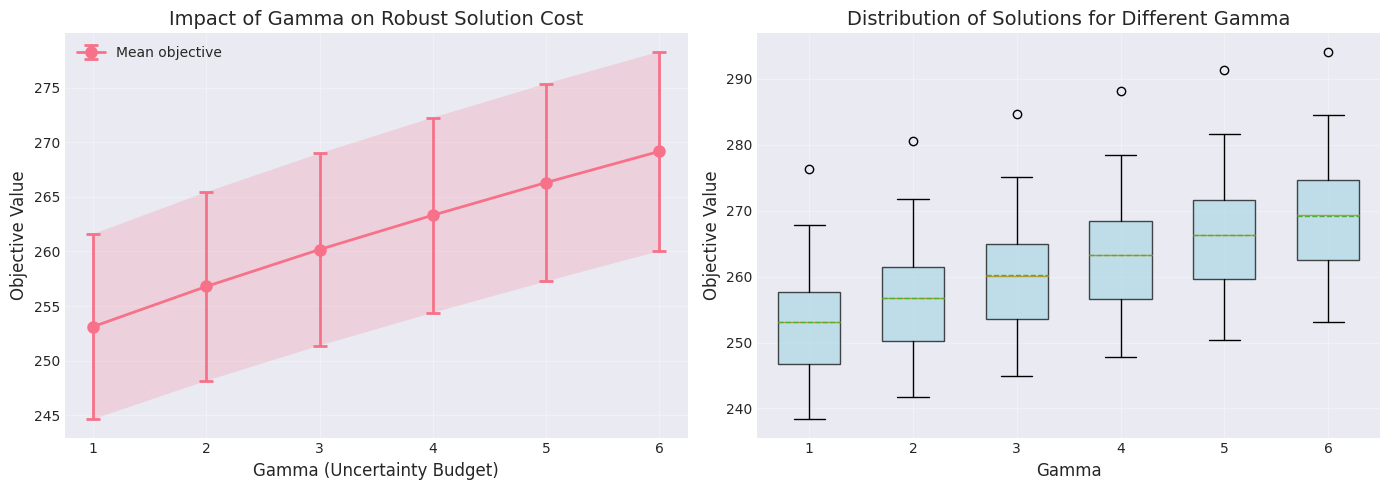

In [6]:
N = 20
results = robust_results[N]
gamma_values = sorted(results.keys())

objectives = [results[g]["in_sample"] for g in gamma_values]
visualizer.plot_robust_gamma_analysis(gamma_values, objectives)

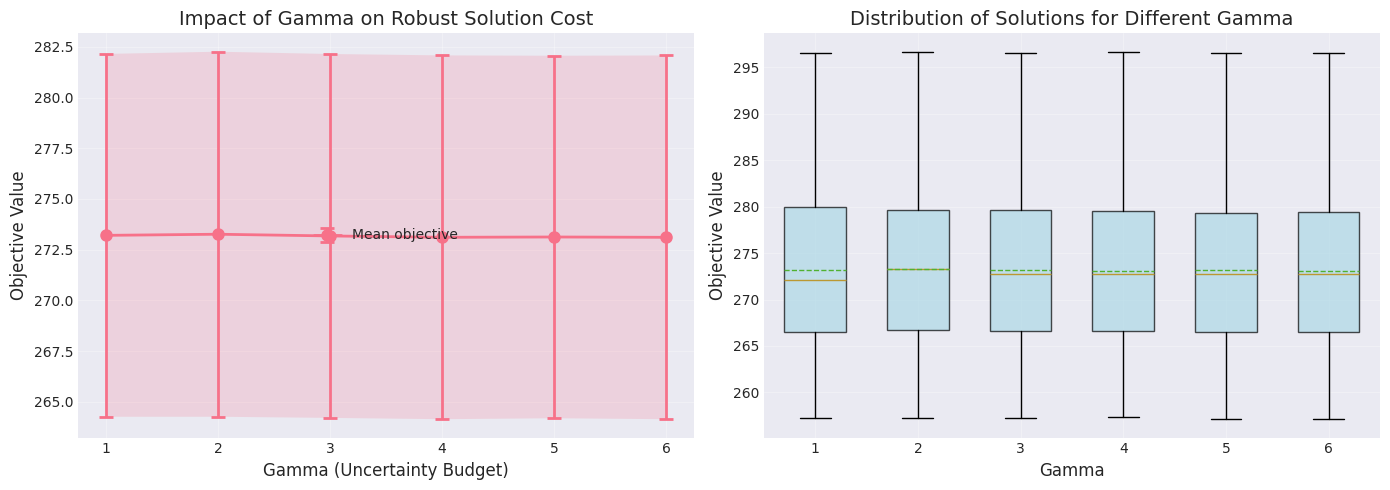

In [7]:
objectives = [results[g]["oos"] for g in gamma_values]
visualizer.plot_robust_gamma_analysis(gamma_values, objectives)

## Stochastic optimization approach

In [8]:
stochastic_rn_results = {}
stochastic_ra_results = {}

for N in N_VALUES:
    print(f"\nRunning stochastic experiments for n={N}")
    rn_result, ra_result = run_stochastic_experiments(
        N, k=30, alpha_values=ALPHA_VALUES, num_instances=NUM_INSTANCES
    )
    stochastic_rn_results[N] = rn_result
    stochastic_ra_results[N] = ra_result

save_results(stochastic_rn_results, Path("experiments/stochastic_risk_neutral_results.json"))
save_results(stochastic_ra_results, Path("experiments/stochastic_risk_averse_results.json"))


Running stochastic experiments for n=5
NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID


Set parameter WLSSecret
Set parameter LicenseID to value 2799306
Academic license 2799306 - for non-commercial use only - registered to se___@business.uzh.ch

Solving Risk-Neutral problems...
RN: mean=55.00, std=0.09, CVaR=60.53

Solving Risk-Averse problems with α=0.5...
  α=0.5: mean=55.00, std=0.09, CVaR=57.54

Solving Risk-Averse problems with α=0.9...
  α=0.9: mean=54.98, std=0.08, CVaR=60.54

Running stochastic experiments for n=10
NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2799306
Academic license 2799306 - for non-commercial use only - registered to se___@business.uzh.ch

Solving Risk-Neutral problems...
RN: mean=185.01, std=0.17, CVaR=195.83

Solving Risk-Averse problems with α=0.5...
  α=0.5: mean=184.95, std=0.20, CVaR=189.82

Solving 

### Risk-Neutral vs Risk-Averse

In [9]:
N = 20
ALPHA = 0.90

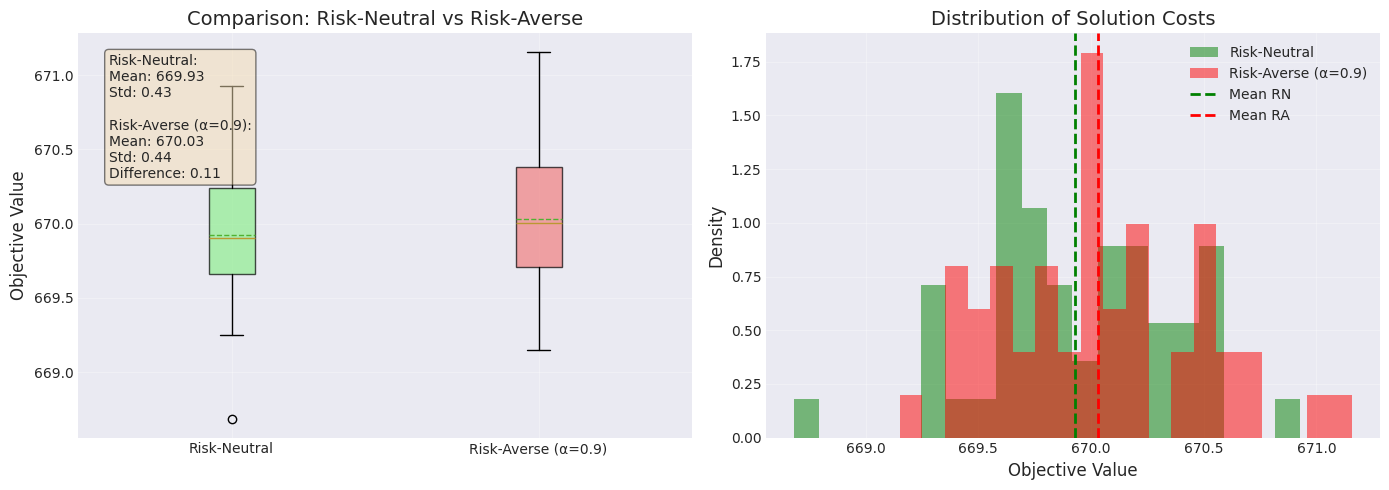

In [10]:
rn_objs = stochastic_rn_results[N]["mean_list"]
ra_objs = stochastic_ra_results[N][ALPHA]["mean_list"]

visualizer.plot_stochastic_comparison(rn_objs, ra_objs, alpha=ALPHA)

### Alpha sensitivity

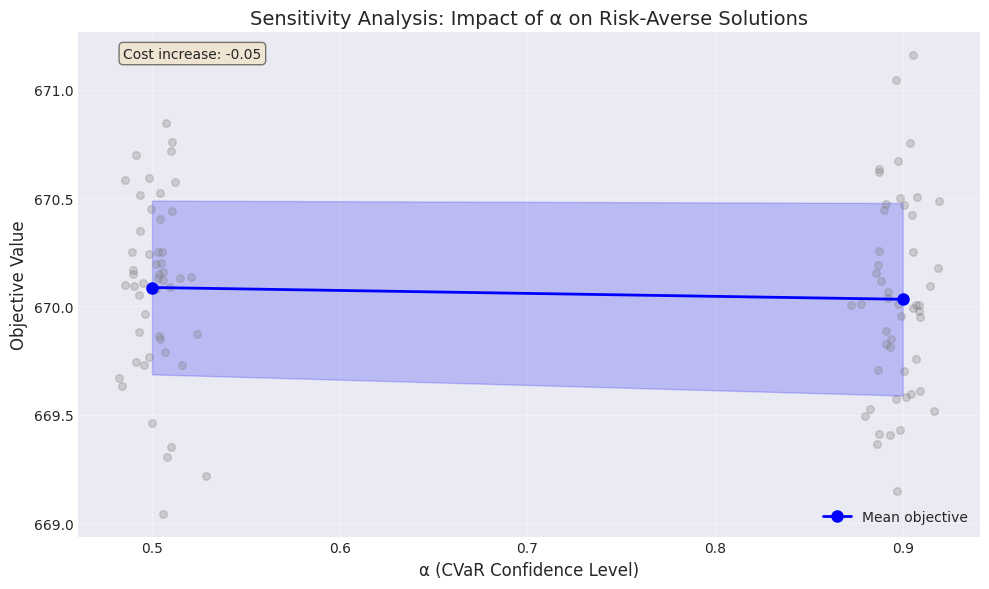

In [11]:
objectives = [stochastic_ra_results[N][a]["mean_list"] for a in ALPHA_VALUES]

visualizer.plot_alpha_sensitivity(ALPHA_VALUES, objectives)

For tail risk

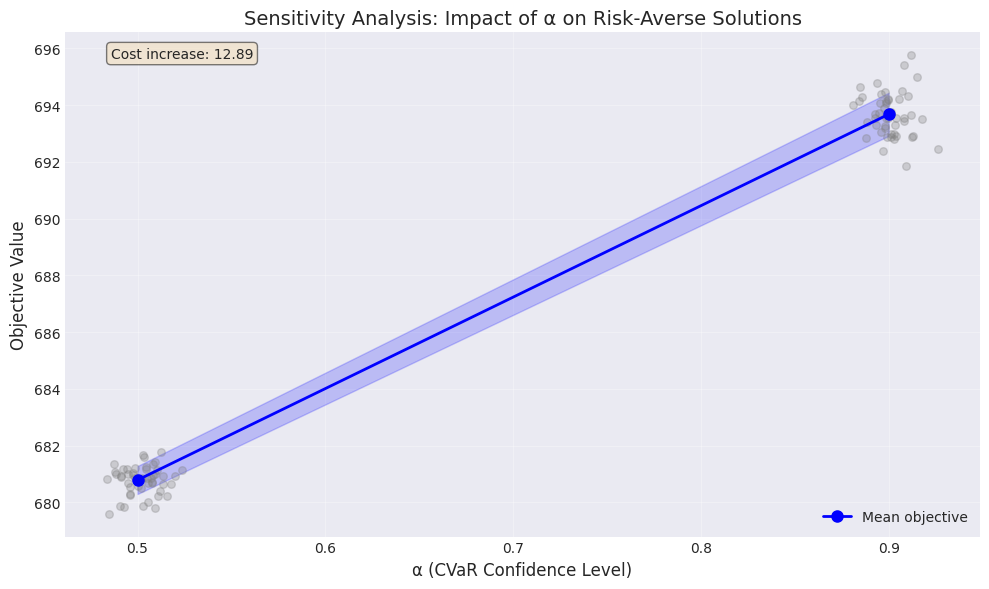

In [12]:
objectives = [stochastic_ra_results[N][a]["cvar_list"] for a in ALPHA_VALUES]
visualizer.plot_alpha_sensitivity(ALPHA_VALUES, objectives)

### Out of sample performance

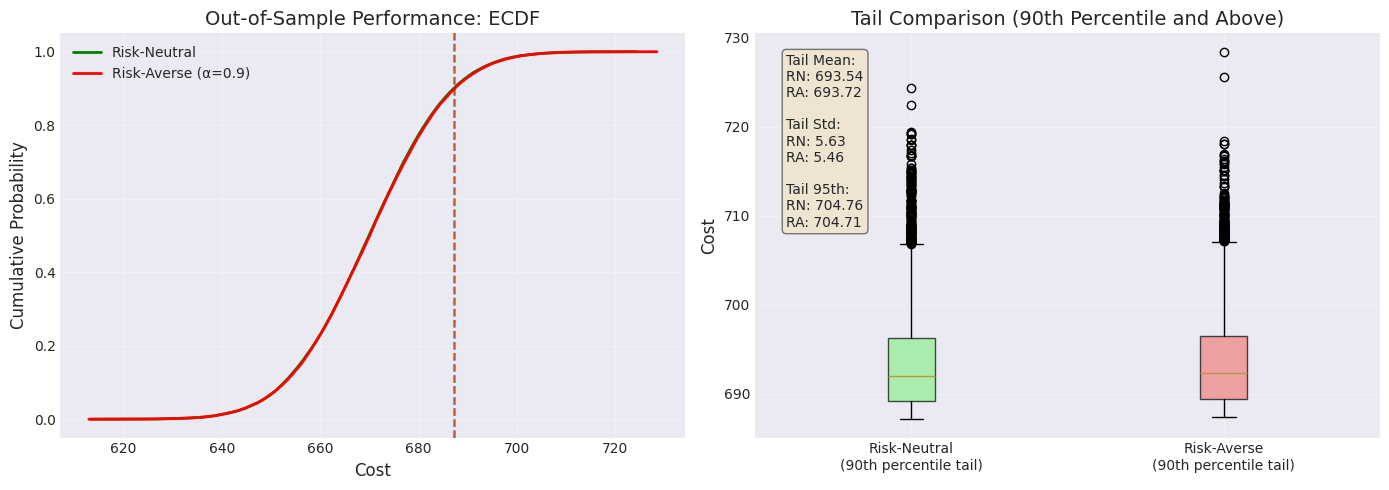

In [13]:
rn_costs = stochastic_rn_results[N]["all_costs"]
ra_costs = stochastic_ra_results[N][ALPHA]["all_costs"]

visualizer.plot_out_of_sample_performance(rn_costs, ra_costs)

### Summary

In [14]:
summary = {}

summary["Risk-Neutral"] = {
    "mean": np.mean(stochastic_rn_results[N]["mean_list"]),
    "std": np.std(stochastic_rn_results[N]["mean_list"]),
    "cvar": np.mean(stochastic_rn_results[N]["cvar_list"]),
    "solve_time": np.mean(stochastic_rn_results[N]["solve_times"]),
}

for ALPHA, res in stochastic_ra_results[N].items():
    summary[f"Risk-Averse α={ALPHA}"] = {
        "mean": res["mean"],
        "std": res["std"],
        "cvar": res["cvar"],
        "solve_time": res["solve_time_mean"],
    }

visualizer.create_summary_table(summary)


SUMMARY OF EXPERIMENT RESULTS
Method                    cvar         mean         solve_time   std         
--------------------------------------------------------------------------------
Risk-Neutral              693.50          669.93          0.006         0.43         
Risk-Averse α=0.5         680.78          670.09          2.920         0.40         
Risk-Averse α=0.9         693.67          670.03          96.415         0.44         


## Scaling experiment

In [15]:
robust_scaling_results, stochastic_scaling_results = run_scaling_experiments(
    sizes=N_VALUES, num_instances_per_size=10
)

save_results(robust_scaling_results, Path("experiments/robust_scaling_results.json"))
save_results(stochastic_scaling_results, Path("experiments/stochastic_scaling_results.json"))

NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2799306
Academic license 2799306 - for non-commercial use only - registered to se___@business.uzh.ch



Testing size n=5...
  Processed 1/10
  Processed 6/10
  n=5: Avg Time=0.004s, Avg Obj=106.10

Testing size n=10...
  Processed 1/10
  Processed 6/10
  n=10: Avg Time=0.005s, Avg Obj=158.41

Testing size n=15...
  Processed 1/10
  Processed 6/10
  n=15: Avg Time=0.014s, Avg Obj=213.89

Testing size n=20...
  Processed 1/10
  Processed 6/10
  n=20: Avg Time=0.022s, Avg Obj=262.38

Testing size n=5...
  n=5: RN Time=0.002s, RA Time=0.013s

Testing size n=10...
  n=10: RN Time=0.003s, RA Time=0.257s

Testing size n=15...
  n=15: RN Time=0.005s, RA Time=6.370s

Testing size n=20...
  n=20: RN Time=0.014s, RA Time=110.762s


In [16]:
robust_2d = [
    [r for r in robust_scaling_results if r['n'] == n]
    for n in N_VALUES
]

rn_2d = [
    [r for r in stochastic_scaling_results 
     if r['n'] == n and r['type'] == 'risk_neutral']
    for n in N_VALUES
]

ra_2d = [
    [r for r in stochastic_scaling_results 
     if r['n'] == n and r['type'] == 'risk_averse']
    for n in N_VALUES
]

### Robust

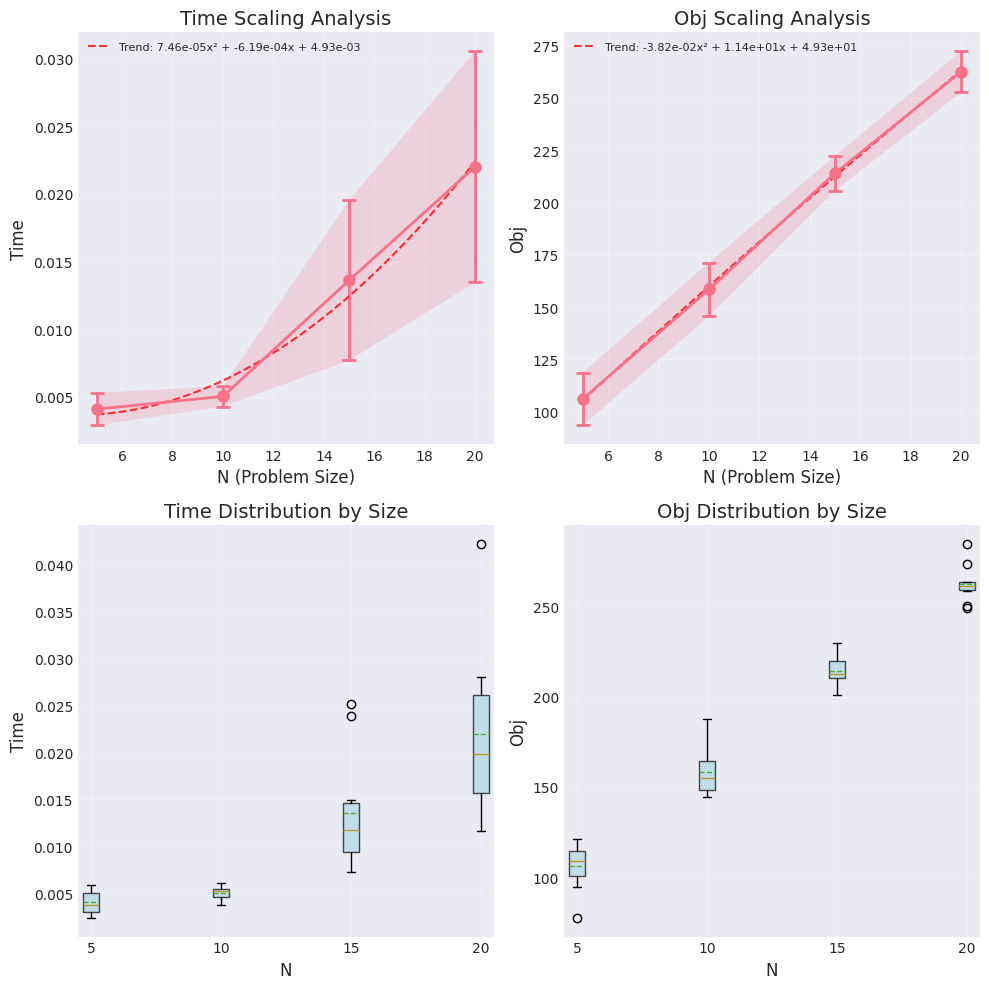

In [17]:
visualizer.plot_scaling_analysis(robust_2d)

### Stochastic Risk-Neutral

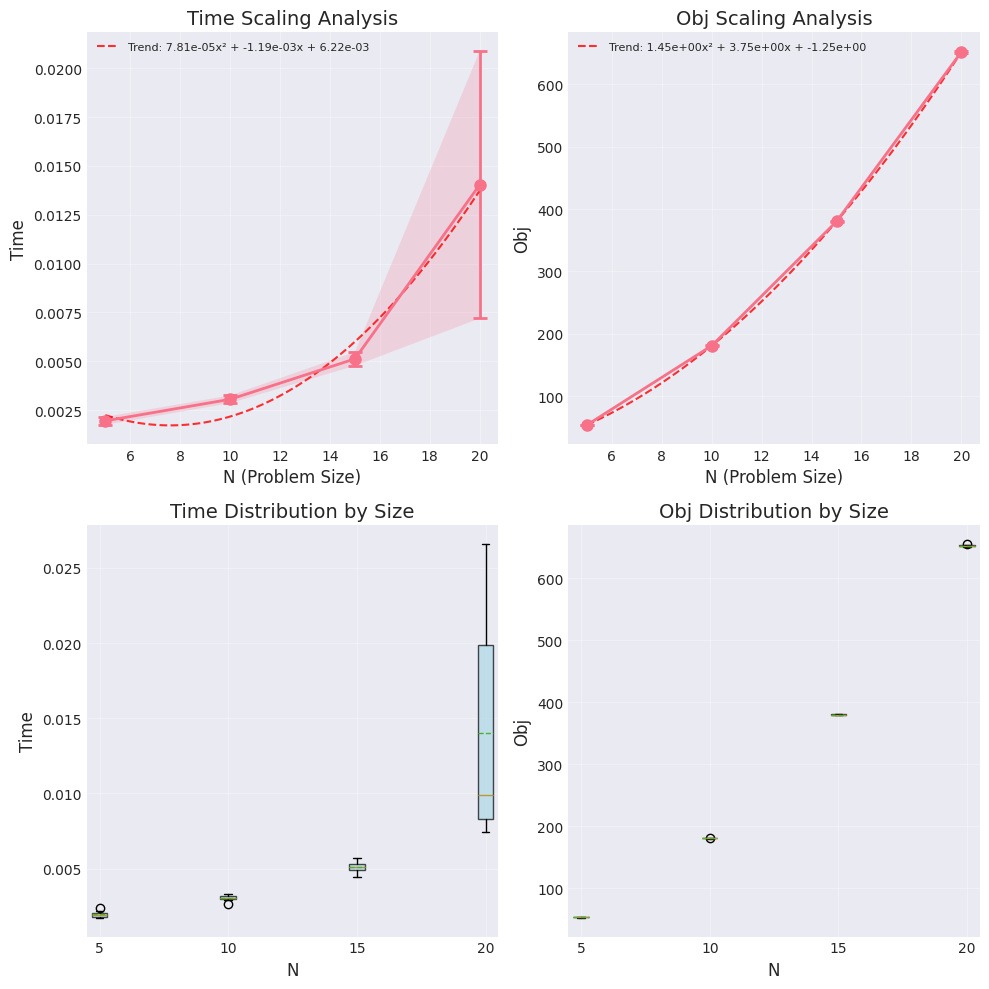

In [18]:
visualizer.plot_scaling_analysis(rn_2d)

### Stochastic Risk-Averse

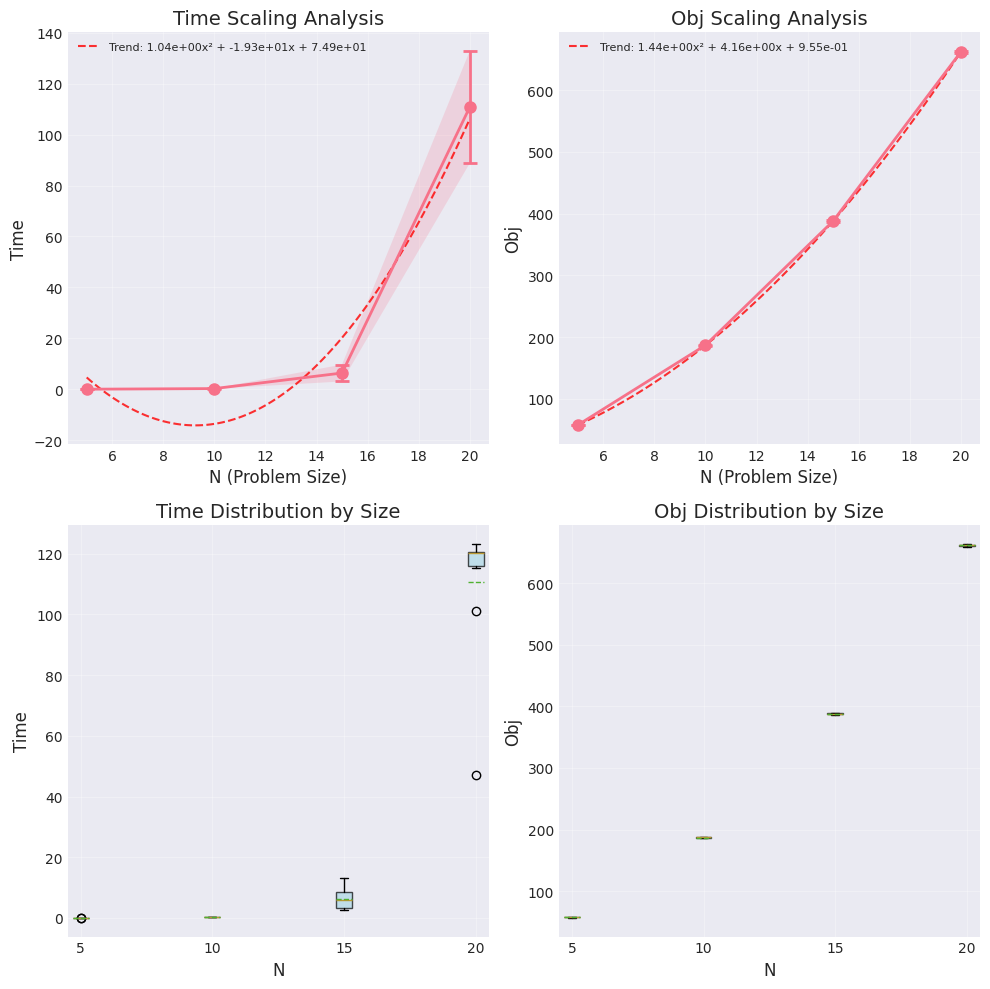

In [19]:
visualizer.plot_scaling_analysis(ra_2d)